# 🌡️ Análisis Exploratorio de Datos (EDA)
## Urban Heat Island — Sevilla

Este cuaderno realiza el análisis exploratorio completo del dataset de píxeles de Sevilla, cubriendo:

1. Carga e inspección inicial de datos  
2. Estadísticas descriptivas  
3. Identificación de valores atípicos  
4. Análisis de correlaciones  
5. Visualizaciones  
6. Resumen ejecutivo

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de estilo para visualizaciones
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Carpeta de salida para gráficos
OUTPUT_PLOTS_DIR = "outputs/eda_plots"
os.makedirs(OUTPUT_PLOTS_DIR, exist_ok=True)

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


## 1. Carga de Datos

In [3]:
CSV_PATH = "outputs/processed/sevilla_pixel_data.csv"
df = pd.read_csv(CSV_PATH)

print(f"Dataset cargado: {CSV_PATH}")
print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado: outputs/processed/sevilla_pixel_data.csv
Dimensiones: 484,356 filas × 12 columnas


## 2. Inspección Inicial

In [4]:
print("--- Primeros 5 Registros ---")
df.head()

--- Primeros 5 Registros ---


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_HighCapacity_m,D2R_Urban_m,Tree_Density_50m,Building_Density_100m,Avg_Building_Height_100m
0,-6.029941,37.449956,0.505166,-0.178238,0.157998,20.000000,40.960874,2743.999249,2776.807410,1,0,0.0
1,-6.029762,37.449956,0.728687,-0.395285,0.181745,20.000000,40.714777,2743.879563,2760.939843,1,0,0.0
2,-6.029582,37.449956,0.763079,-0.424442,0.149877,20.000000,40.714777,2743.851804,2745.072446,1,0,0.0
3,-6.029402,37.449956,0.775685,-0.418584,0.147389,22.360680,40.379811,2743.915975,2729.205220,1,0,0.0
4,-6.029223,37.449956,0.835151,-0.530323,0.201774,28.284271,40.379811,2744.072070,2713.338171,1,0,0.0


In [5]:
print("--- Información General del Dataset ---")
df.info()

--- Información General del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 484356 entries, 0 to 484355
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Longitude                 484356 non-null  float64
 1   Latitude                  484356 non-null  float64
 2   NDVI                      484356 non-null  float64
 3   NDBI                      484356 non-null  float64
 4   Albedo                    484356 non-null  float64
 5   D2W_meters                484356 non-null  float64
 6   LST_Target                484356 non-null  float64
 7   D2R_HighCapacity_m        484356 non-null  float64
 8   D2R_Urban_m               484356 non-null  float64
 9   Tree_Density_50m          484356 non-null  int64  
 10  Building_Density_100m     484356 non-null  int64  
 11  Avg_Building_Height_100m  484356 non-null  float64
dtypes: float64(10), int64(2)
memory usage: 44.3 MB


In [6]:
print("--- Valores Nulos por Columna ---")
print(df.isnull().sum())

print(f"\n--- Duplicados ---")
print(f"Filas duplicadas: {df.duplicated().sum()}")

--- Valores Nulos por Columna ---
Longitude                   0
Latitude                    0
NDVI                        0
NDBI                        0
Albedo                      0
D2W_meters                  0
LST_Target                  0
D2R_HighCapacity_m          0
D2R_Urban_m                 0
Tree_Density_50m            0
Building_Density_100m       0
Avg_Building_Height_100m    0
dtype: int64

--- Duplicados ---
Filas duplicadas: 0


## 3. Estadísticas Descriptivas

In [7]:
print("--- Estadísticas Generales ---")
df.describe()

--- Estadísticas Generales ---


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_HighCapacity_m,D2R_Urban_m,Tree_Density_50m,Building_Density_100m,Avg_Building_Height_100m
count,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000
mean,-5.964993,37.389948,0.228368,0.027242,0.214880,205.498991,47.493737,1045.237005,515.597233,0.509282,6.094680,3.114771
std,0.037550,0.034697,0.221364,0.142571,0.063660,192.415219,4.003924,735.432380,525.794595,0.712064,20.578382,8.044551
min,-6.029941,37.329941,-1.000000,-0.630200,0.002293,0.000000,29.594249,0.550402,0.023918,0.000000,0.000000,0.000000
25%,-5.997467,37.359945,0.095436,-0.038156,0.179143,70.710678,45.500005,435.516839,142.851480,0.000000,0.000000,0.000000
50%,-5.964993,37.389948,0.178871,0.049435,0.210855,142.126704,47.769570,899.446439,331.665343,0.000000,0.000000,0.000000
75%,-5.932519,37.419952,0.331392,0.115421,0.244974,281.602557,50.254471,1533.010914,693.351618,1.000000,3.000000,6.000000
max,-5.900045,37.449956,0.927826,1.000000,0.808436,1368.831619,58.939659,3481.639356,2969.474517,7.000000,451.000000,938.400000


## 4. Identificación de Valores Atípicos (Outliers)

In [8]:
outlier_rows = []
for col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers_count = ((df[col] < lower) | (df[col] > upper)).sum()
    z_scores = np.abs(stats.zscore(df[col]))
    extreme = (z_scores > 3).sum()
    outlier_rows.append({
        'Variable': col,
        'Límite Inferior (IQR)': round(lower, 4),
        'Límite Superior (IQR)': round(upper, 4),
        'Outliers IQR (n)': outliers_count,
        'Outliers IQR (%)': round(outliers_count / len(df) * 100, 2),
        'Outliers extremos |Z|>3': extreme,
    })

pd.DataFrame(outlier_rows).set_index('Variable')

,Límite Inferior (IQR),Límite Superior (IQR),Outliers IQR (n),Outliers IQR (%),Outliers extremos |Z|>3
Variable,,,,,
Longitude,-6.0949,-5.8351,0,0.00,0
Latitude,37.2699,37.5100,0,0.00,0
NDVI,-0.2585,0.6853,30758,6.35,4871
NDBI,-0.2685,0.3458,24013,4.96,8098
Albedo,0.0804,0.3437,23139,4.78,6952
D2W_meters,-245.6271,597.9404,24772,5.11,8866
LST_Target,38.3683,57.3862,15716,3.24,5515
D2R_HighCapacity_m,-1210.7243,3179.2520,738,0.15,438
D2R_Urban_m,-682.8987,1519.1018,33745,6.97,10407


## 5. Análisis de Correlaciones

In [9]:
correlation_matrix = df.corr()

print("--- Correlaciones con LST_Target (ordenadas) ---")
correlations_with_target = correlation_matrix['LST_Target'].sort_values(ascending=False)
print(correlations_with_target)

correlation_matrix

--- Correlaciones con LST_Target (ordenadas) ---
LST_Target                  1.000000
NDBI                        0.460517
Longitude                   0.371592
Albedo                      0.362838
D2W_meters                  0.056105
Tree_Density_50m           -0.011593
D2R_Urban_m                -0.014635
Avg_Building_Height_100m   -0.035334
Building_Density_100m      -0.067488
Latitude                   -0.131786
D2R_HighCapacity_m         -0.140678
NDVI                       -0.204528
Name: LST_Target, dtype: float64


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target,D2R_HighCapacity_m,D2R_Urban_m,Tree_Density_50m,Building_Density_100m,Avg_Building_Height_100m
Longitude,1.000000e+00,-5.140059e-15,0.009450,0.150665,0.137083,0.249084,0.371592,0.109254,0.157677,-0.000129,-0.159048,-0.029445
Latitude,-5.140059e-15,1.000000e+00,0.180661,-0.178941,-0.140529,0.188442,-0.131786,0.169766,0.217791,0.011926,-0.001064,-0.037498
NDVI,9.449512e-03,1.806612e-01,1.000000,-0.588444,-0.066930,0.221116,-0.204528,0.079462,0.174849,0.004615,-0.096790,-0.061753
NDBI,1.506651e-01,-1.789413e-01,-0.588444,1.000000,-0.055183,-0.033229,0.460517,-0.060188,-0.109186,-0.006948,0.083030,0.036894
Albedo,1.370831e-01,-1.405292e-01,-0.066930,-0.055183,1.000000,0.103483,0.362838,-0.029032,0.094528,-0.004933,-0.008974,-0.042564
D2W_meters,2.490840e-01,1.884421e-01,0.221116,-0.033229,0.103483,1.000000,0.056105,0.195804,0.487531,-0.002340,-0.156052,-0.210337
LST_Target,3.715924e-01,-1.317860e-01,-0.204528,0.460517,0.362838,0.056105,1.000000,-0.140678,-0.014635,-0.011593,-0.067488,-0.035334
D2R_HighCapacity_m,1.092544e-01,1.697659e-01,0.079462,-0.060188,-0.029032,0.195804,-0.140678,1.000000,0.278118,-0.000544,0.106691,0.074267
D2R_Urban_m,1.576769e-01,2.177914e-01,0.174849,-0.109186,0.094528,0.487531,-0.014635,0.278118,1.000000,-0.003756,-0.169601,-0.204850
Tree_Density_50m,-1.290324e-04,1.192586e-02,0.004615,-0.006948,-0.004933,-0.002340,-0.011593,-0.000544,-0.003756,1.000000,0.003459,0.026948


## 6. Visualizaciones

### 6.1 Histogramas de Distribución

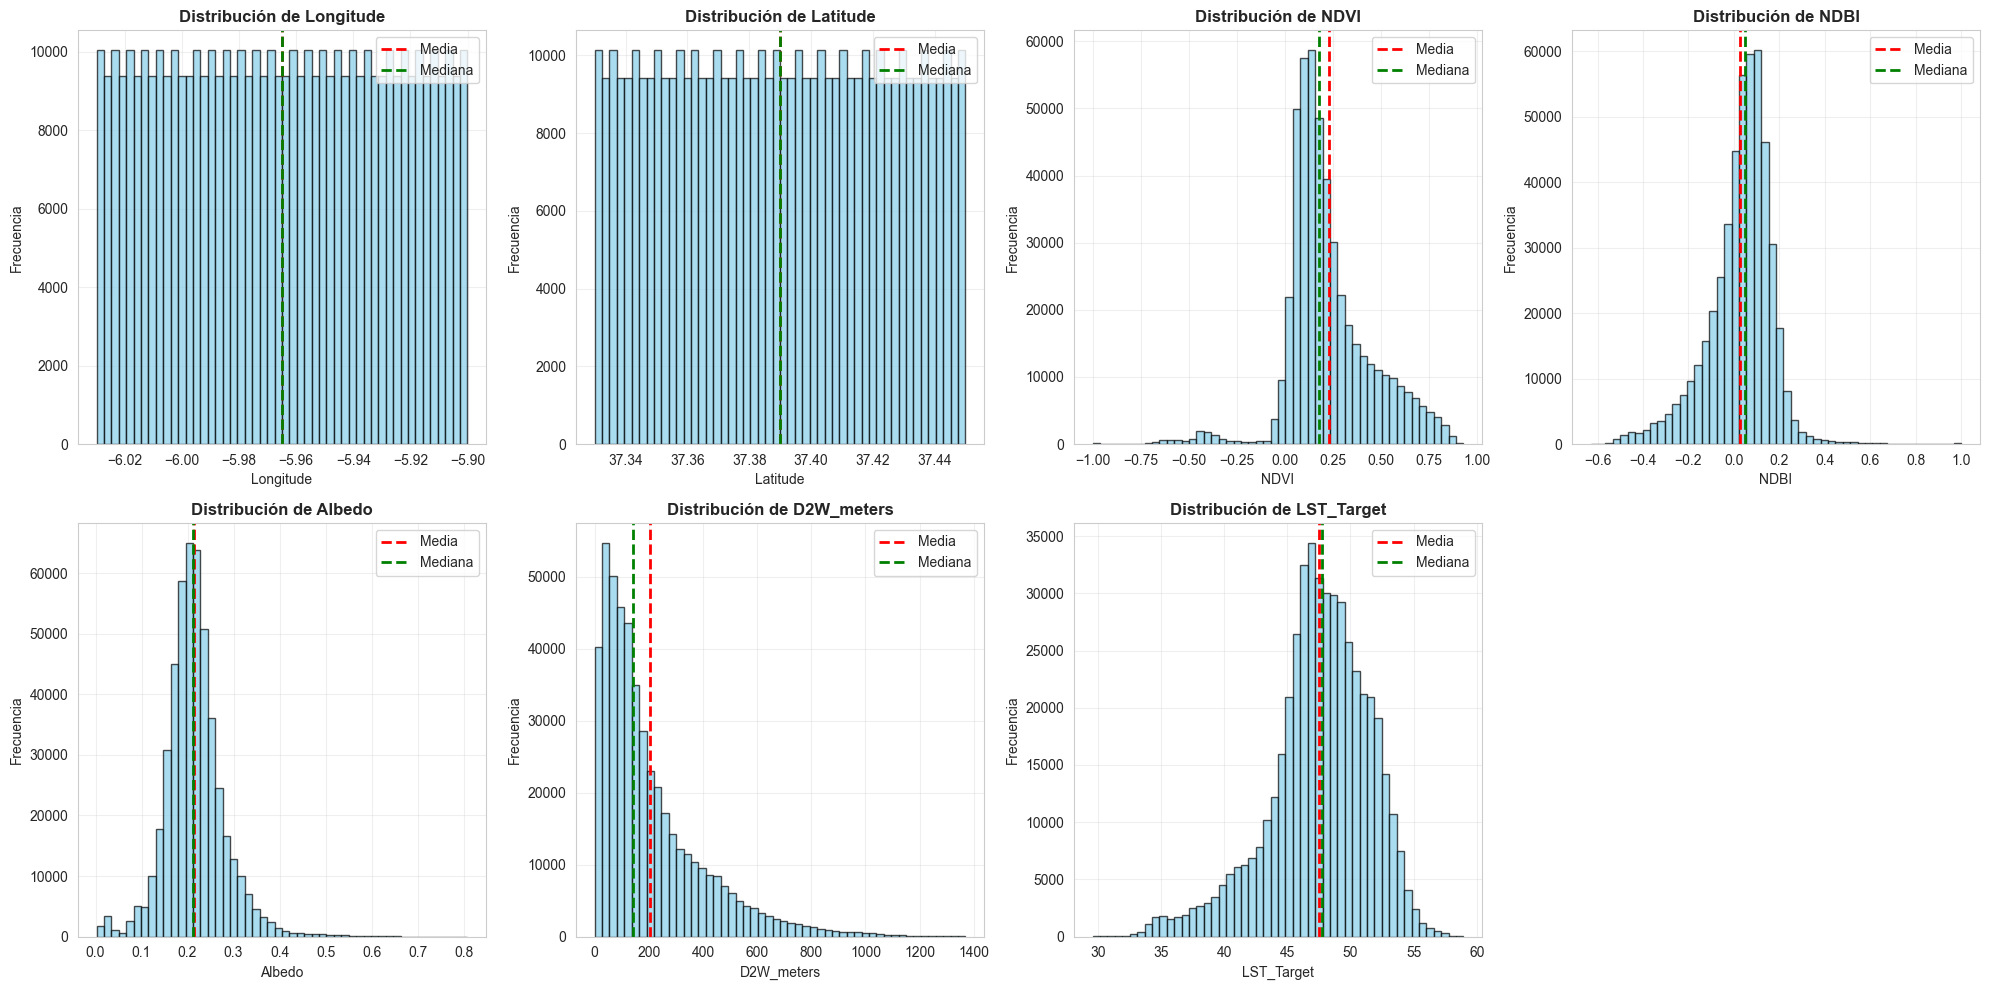

In [53]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label='Media')
    axes[idx].axvline(df[col].median(), color='green', linestyle='--', linewidth=2, label='Mediana')
    axes[idx].legend()

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/1_histogramas.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Boxplots para Detección de Outliers

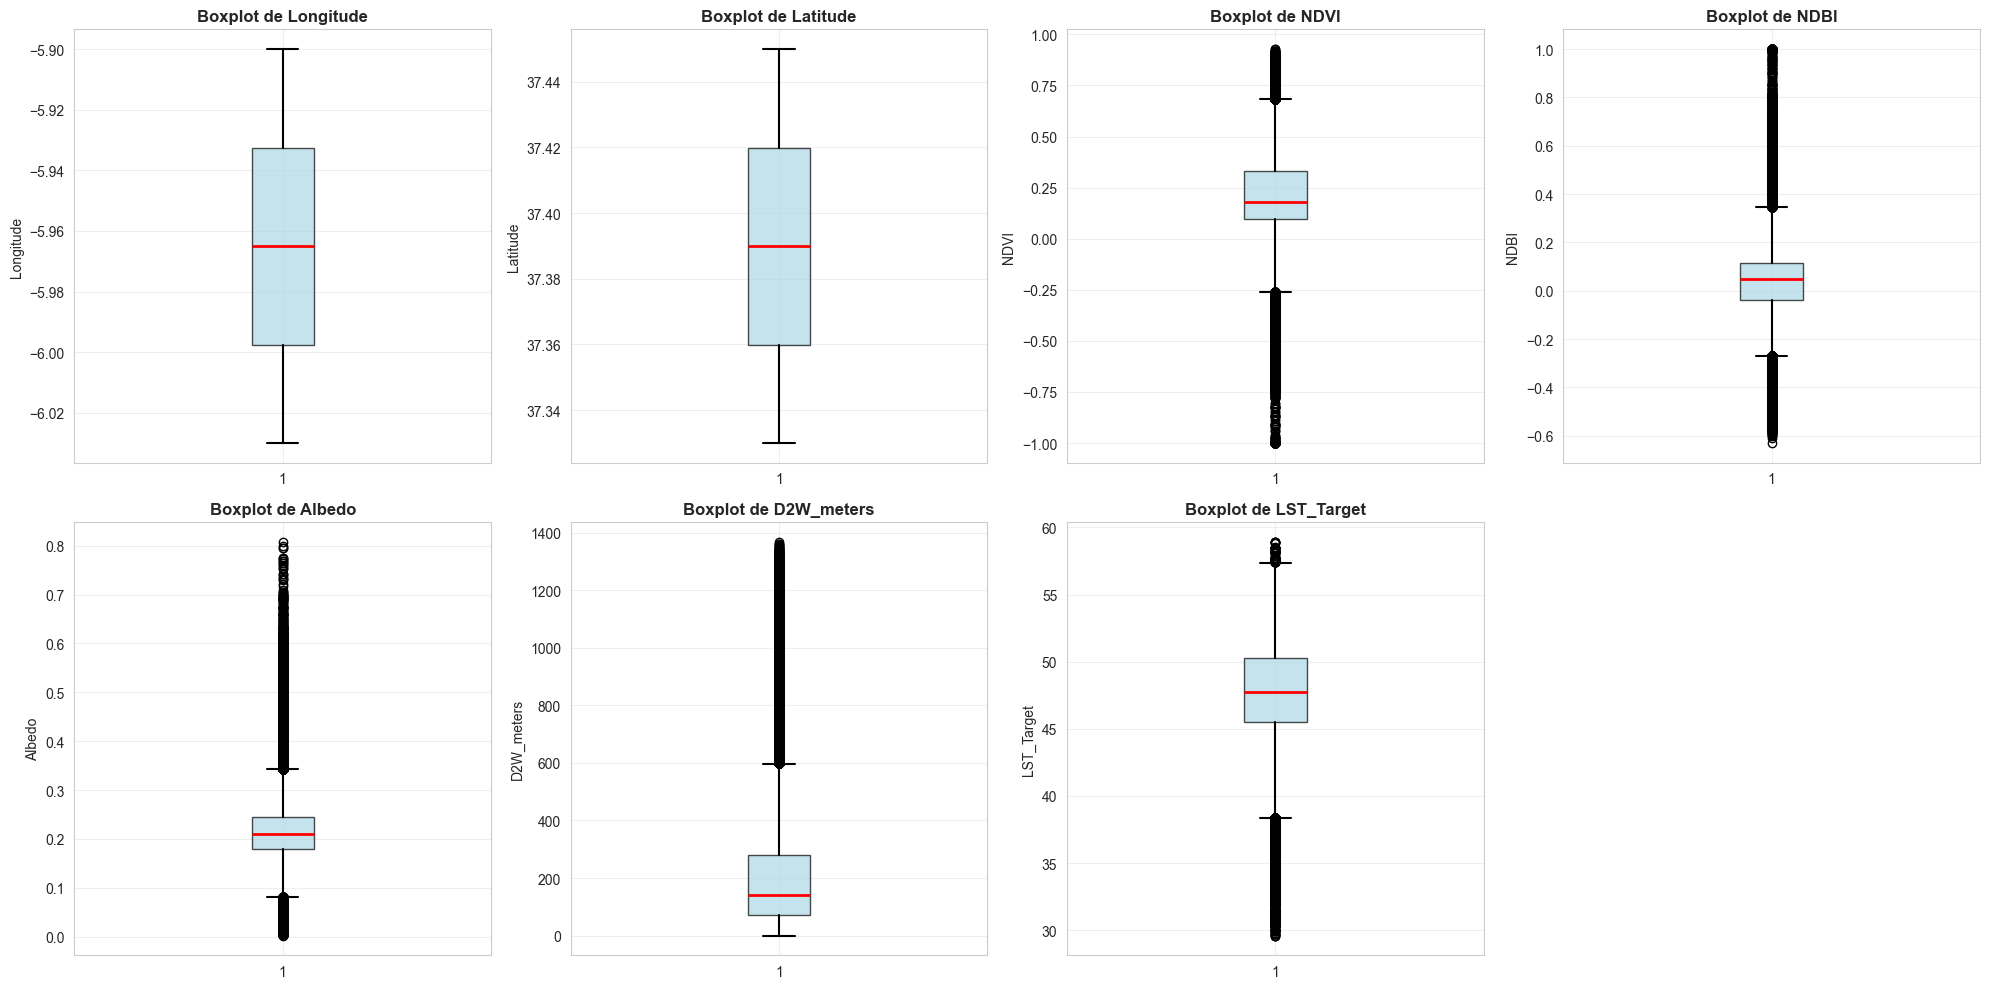

In [54]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     medianprops=dict(color='red', linewidth=2),
                     whiskerprops=dict(linewidth=1.5),
                     capprops=dict(linewidth=1.5))
    axes[idx].set_title(f'Boxplot de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(True, alpha=0.3)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/2_boxplots.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Mapa de Calor de Correlaciones

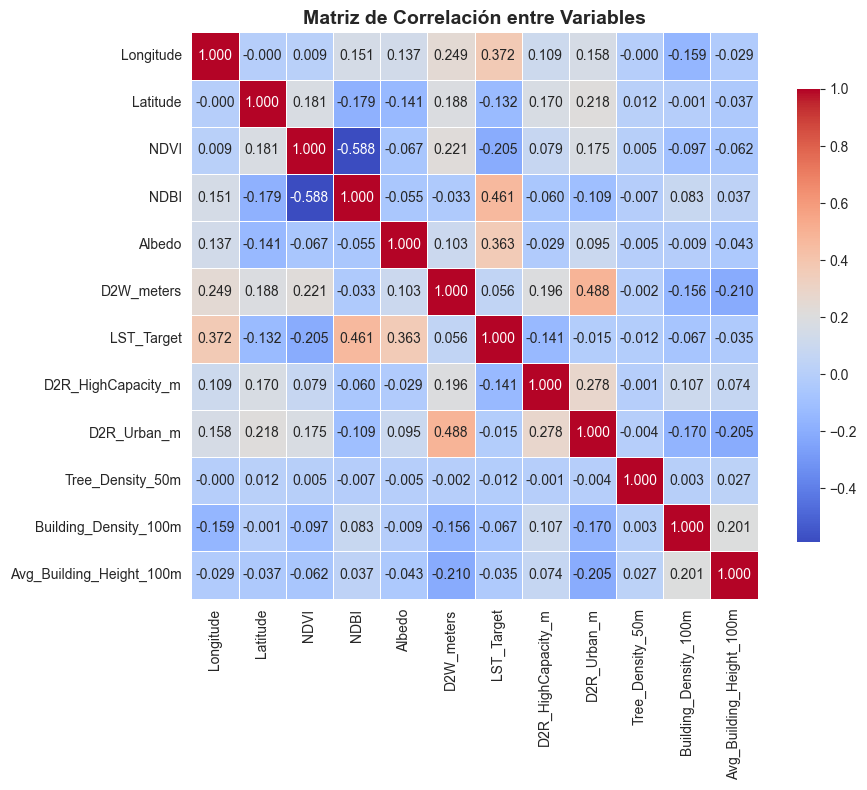

                          Longitude  Latitude   NDVI   NDBI  Albedo  D2W_meters  LST_Target  D2R_HighCapacity_m  D2R_Urban_m  Tree_Density_50m  Building_Density_100m  Avg_Building_Height_100m
Longitude                     1.000    -0.000  0.009  0.151   0.137       0.249       0.372               0.109        0.158            -0.000                 -0.159                    -0.029
Latitude                     -0.000     1.000  0.181 -0.179  -0.141       0.188      -0.132               0.170        0.218             0.012                 -0.001                    -0.037
NDVI                          0.009     0.181  1.000 -0.588  -0.067       0.221      -0.205               0.079        0.175             0.005                 -0.097                    -0.062
NDBI                          0.151    -0.179 -0.588  1.000  -0.055      -0.033       0.461              -0.060       -0.109            -0.007                  0.083                     0.037
Albedo                        0.137    -

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación entre Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/3_correlacion_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print(correlation_matrix.to_string(float_format=lambda x: f"{x:.3f}"))

### 6.4 Pairplot (Relaciones Multivariadas)

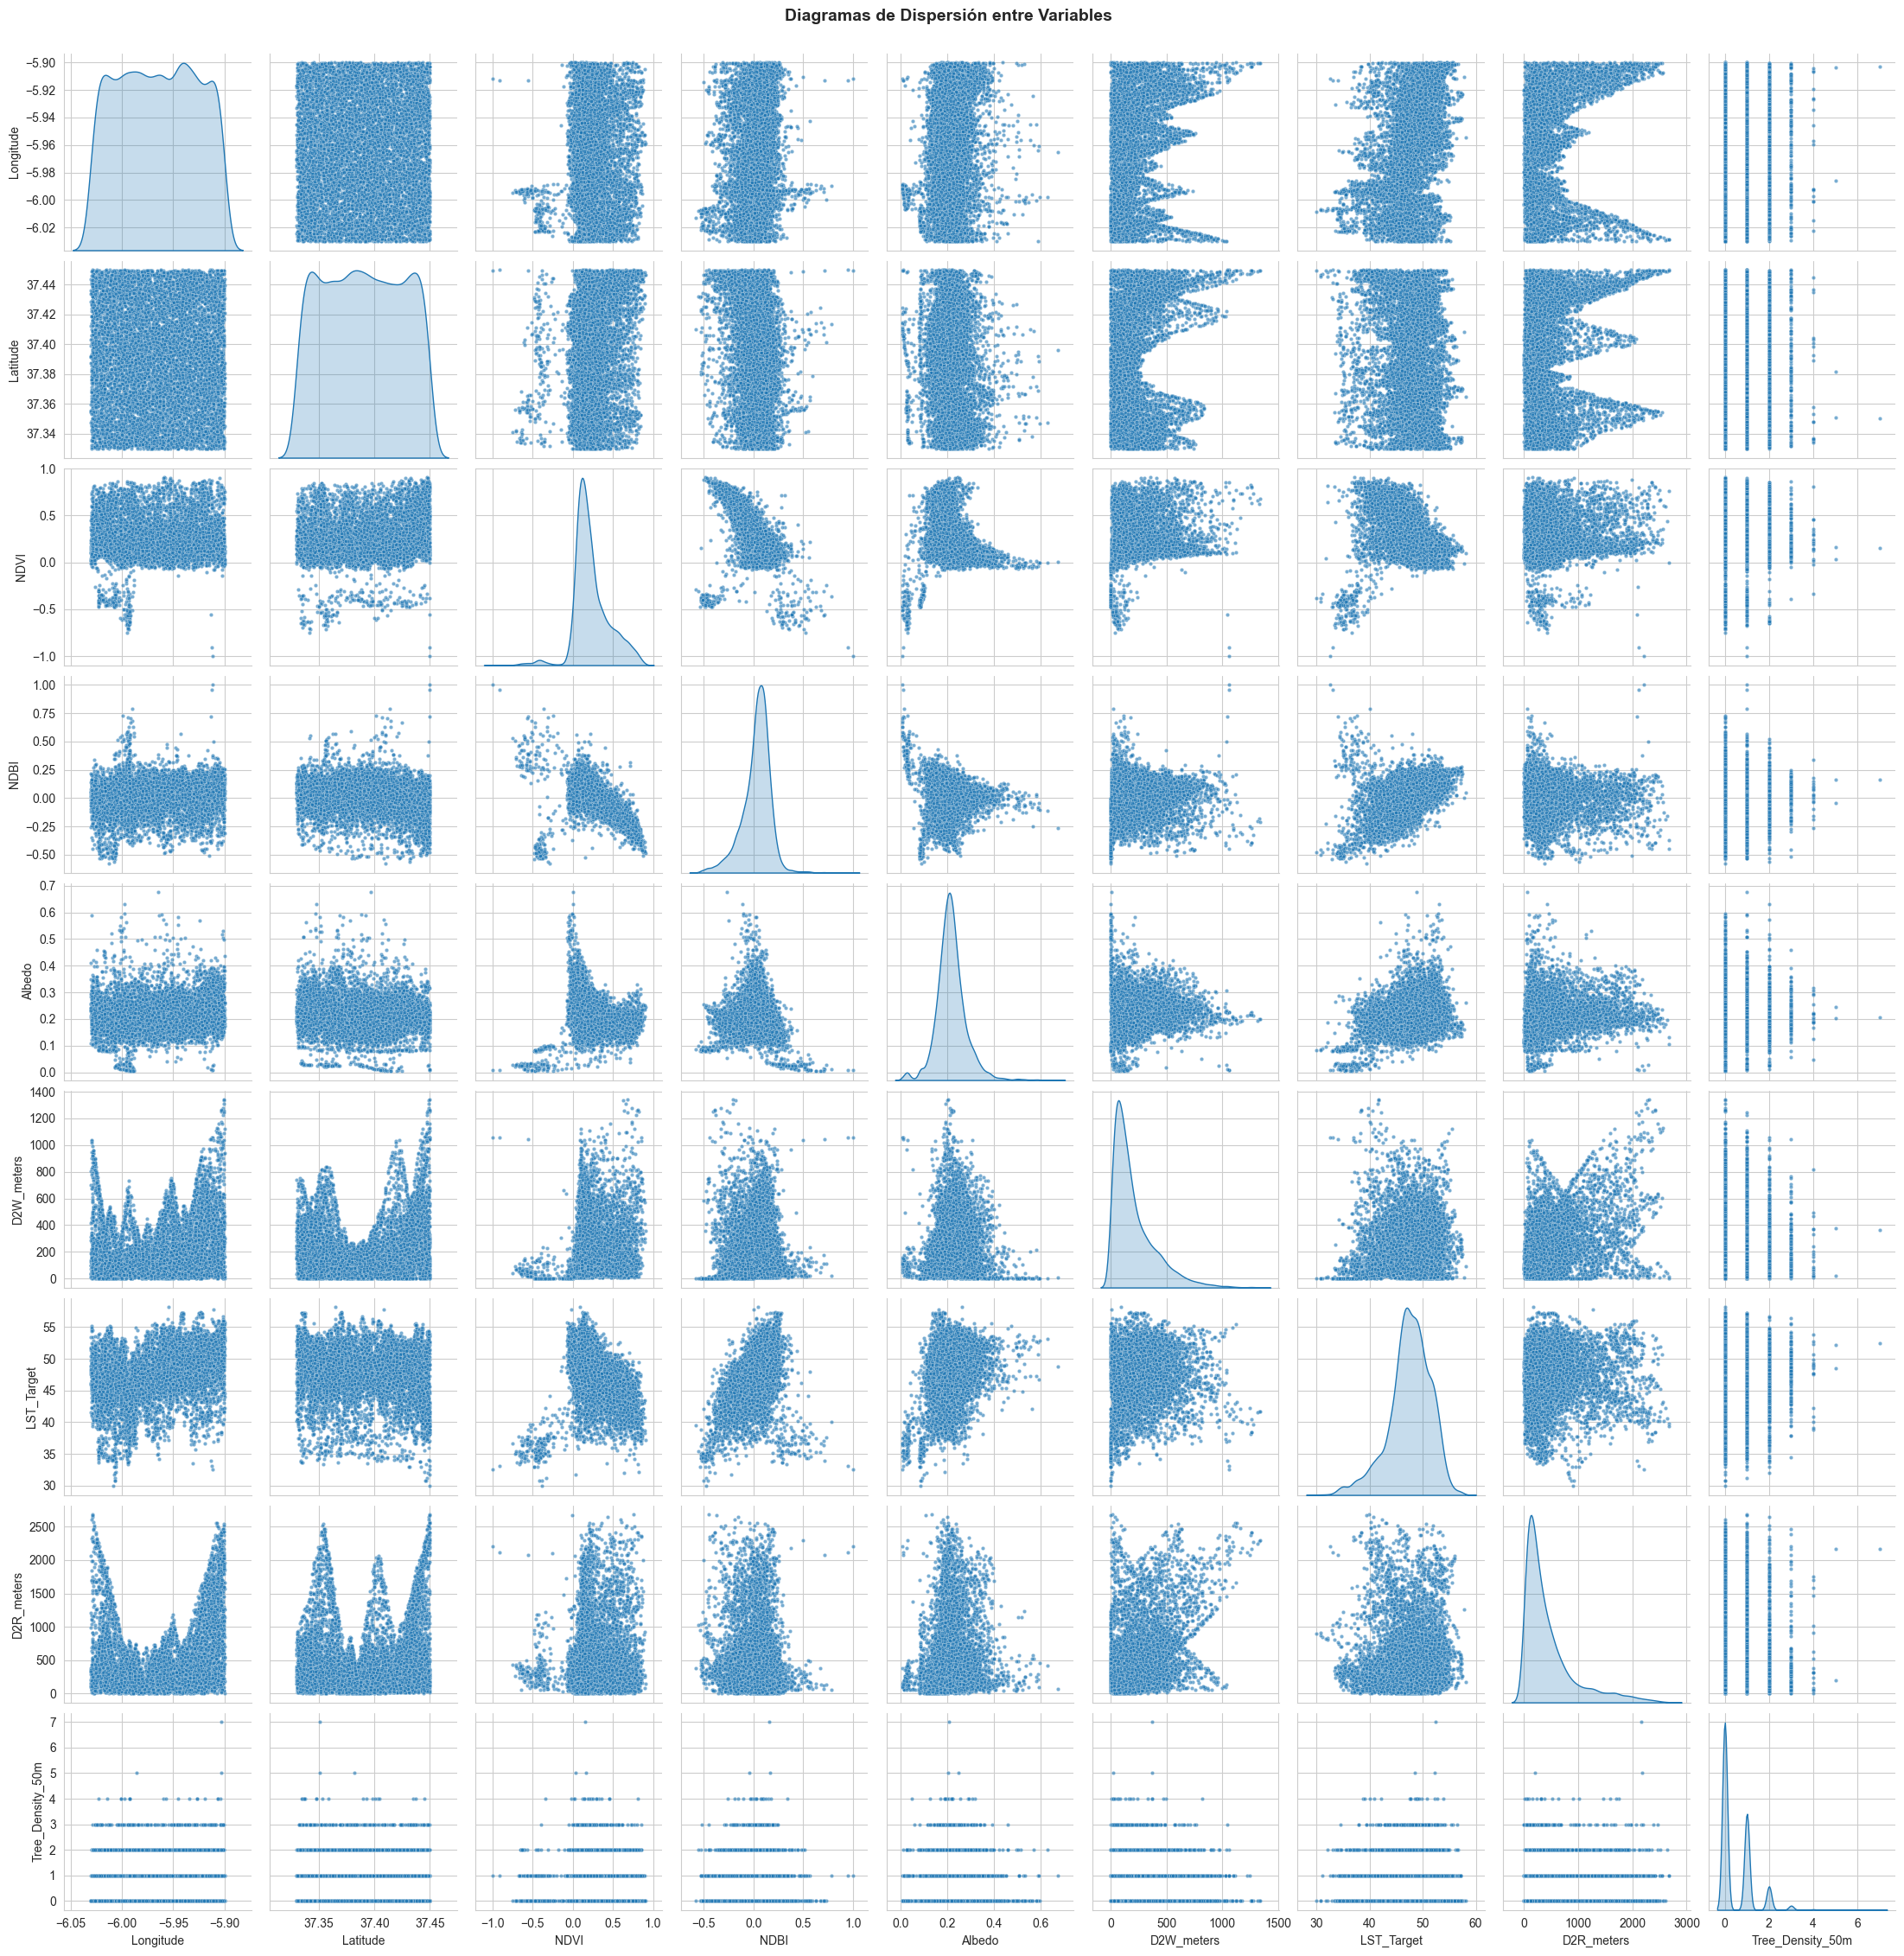

In [11]:
sample_size = min(10000, len(df))
df_sample = df.sample(n=sample_size, random_state=42)

pairplot = sns.pairplot(df_sample, diag_kind='kde', plot_kws={'alpha': 0.6, 's': 10})
pairplot.fig.suptitle('Diagramas de Dispersión entre Variables', y=1.01, fontsize=14, fontweight='bold')
plt.savefig(f"{OUTPUT_PLOTS_DIR}/4_pairplot.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Scatter Plots: Features vs LST_Target

IndexError: index 6 is out of bounds for axis 0 with size 6

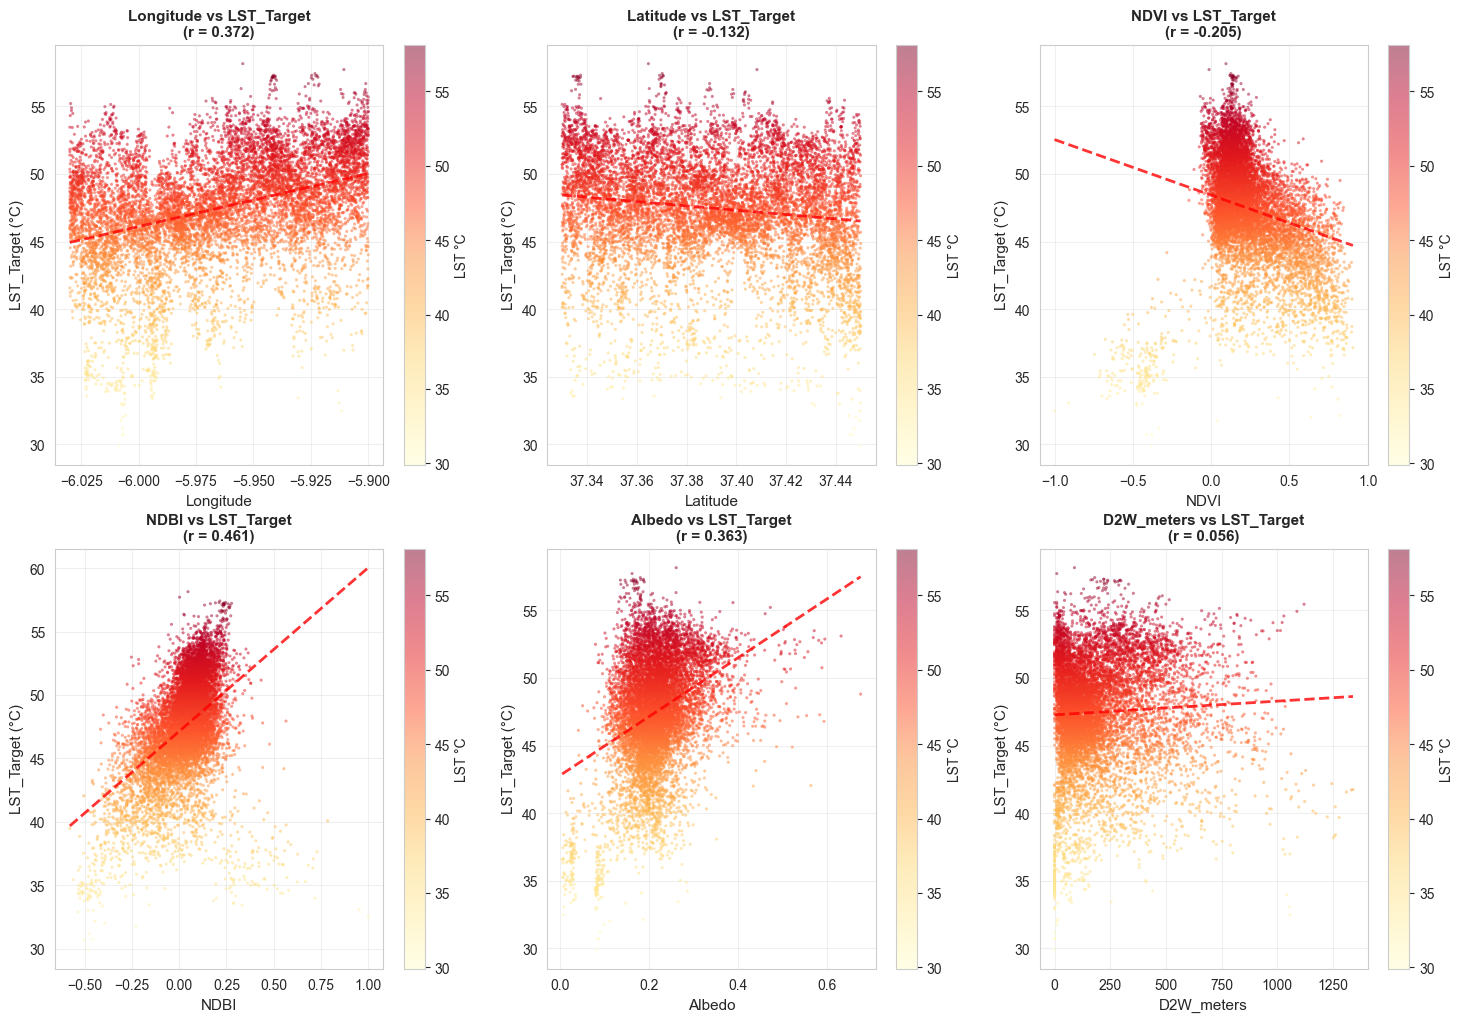

In [12]:
features = [col for col in df.columns if col != 'LST_Target']
sample = df_sample if len(df) > 10000 else df

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, feature in enumerate(features):
    scatter = axes[idx].scatter(sample[feature], sample['LST_Target'],
                               c=sample['LST_Target'], cmap='YlOrRd',
                               alpha=0.5, s=5, edgecolors='none')
    axes[idx].set_xlabel(feature, fontsize=11)
    axes[idx].set_ylabel('LST_Target (°C)', fontsize=11)
    axes[idx].set_title(f'{feature} vs LST_Target\n(r = {correlation_matrix.loc[feature, "LST_Target"]:.3f})',
                       fontsize=11, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    z = np.polyfit(sample[feature], sample['LST_Target'], 1)
    p = np.poly1d(z)
    axes[idx].plot(sorted(sample[feature]), p(sorted(sample[feature])), "r--", alpha=0.8, linewidth=2)
    plt.colorbar(scatter, ax=axes[idx], label='LST °C')

plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/5_scatter_features_vs_target.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Mapa Espacial de LST

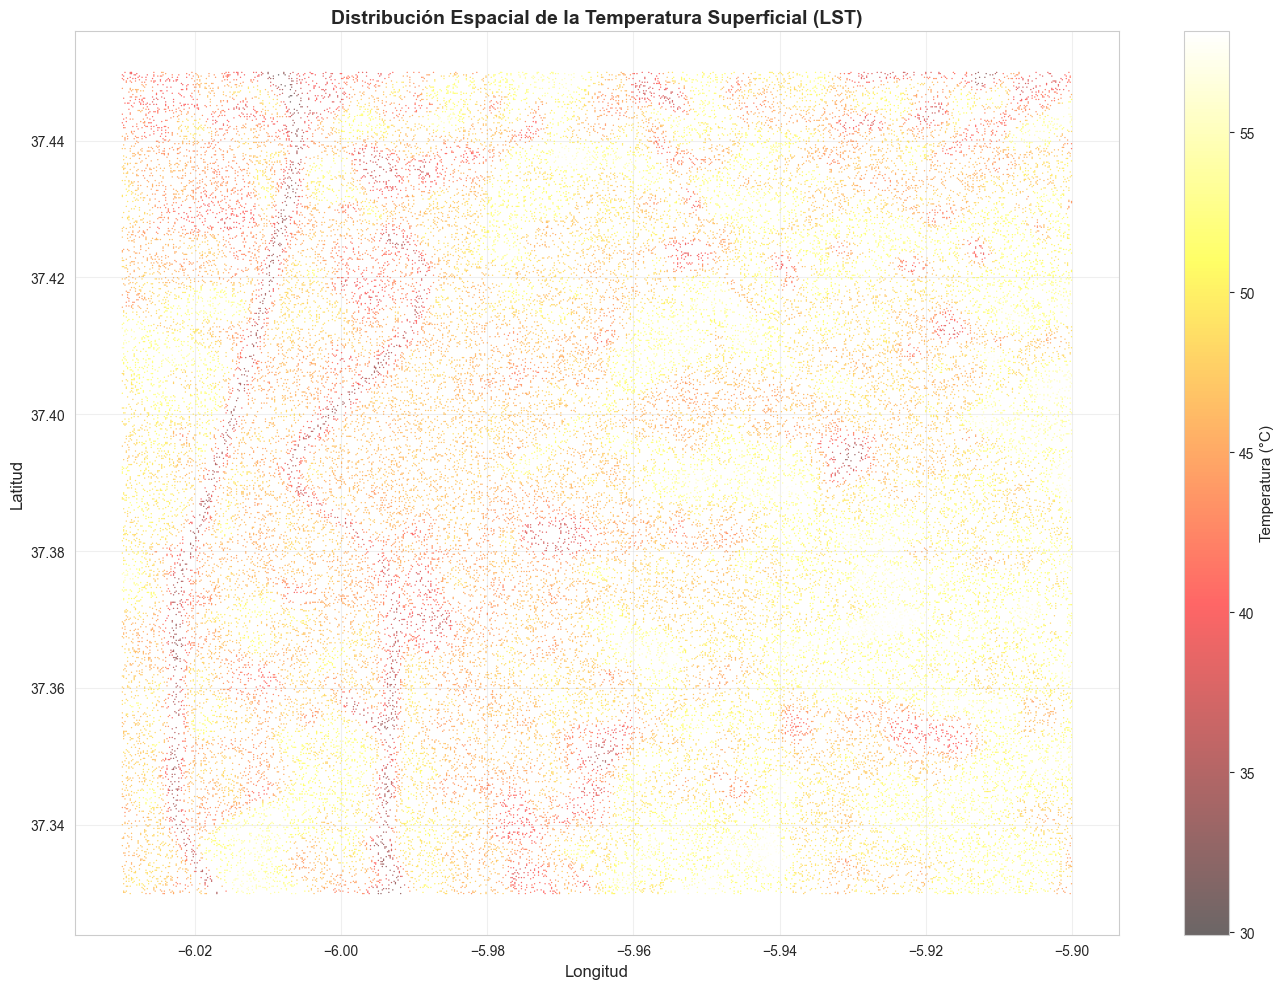

In [13]:
spatial_sample = df.sample(n=min(50000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(spatial_sample['Longitude'], spatial_sample['Latitude'],
                    c=spatial_sample['LST_Target'], cmap='hot',
                    s=1, alpha=0.6, edgecolors='none')
ax.set_xlabel('Longitud', fontsize=12)
ax.set_ylabel('Latitud', fontsize=12)
ax.set_title('Distribución Espacial de la Temperatura Superficial (LST)',
             fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Temperatura (°C)', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/6_mapa_espacial_lst.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.7 Violin Plots

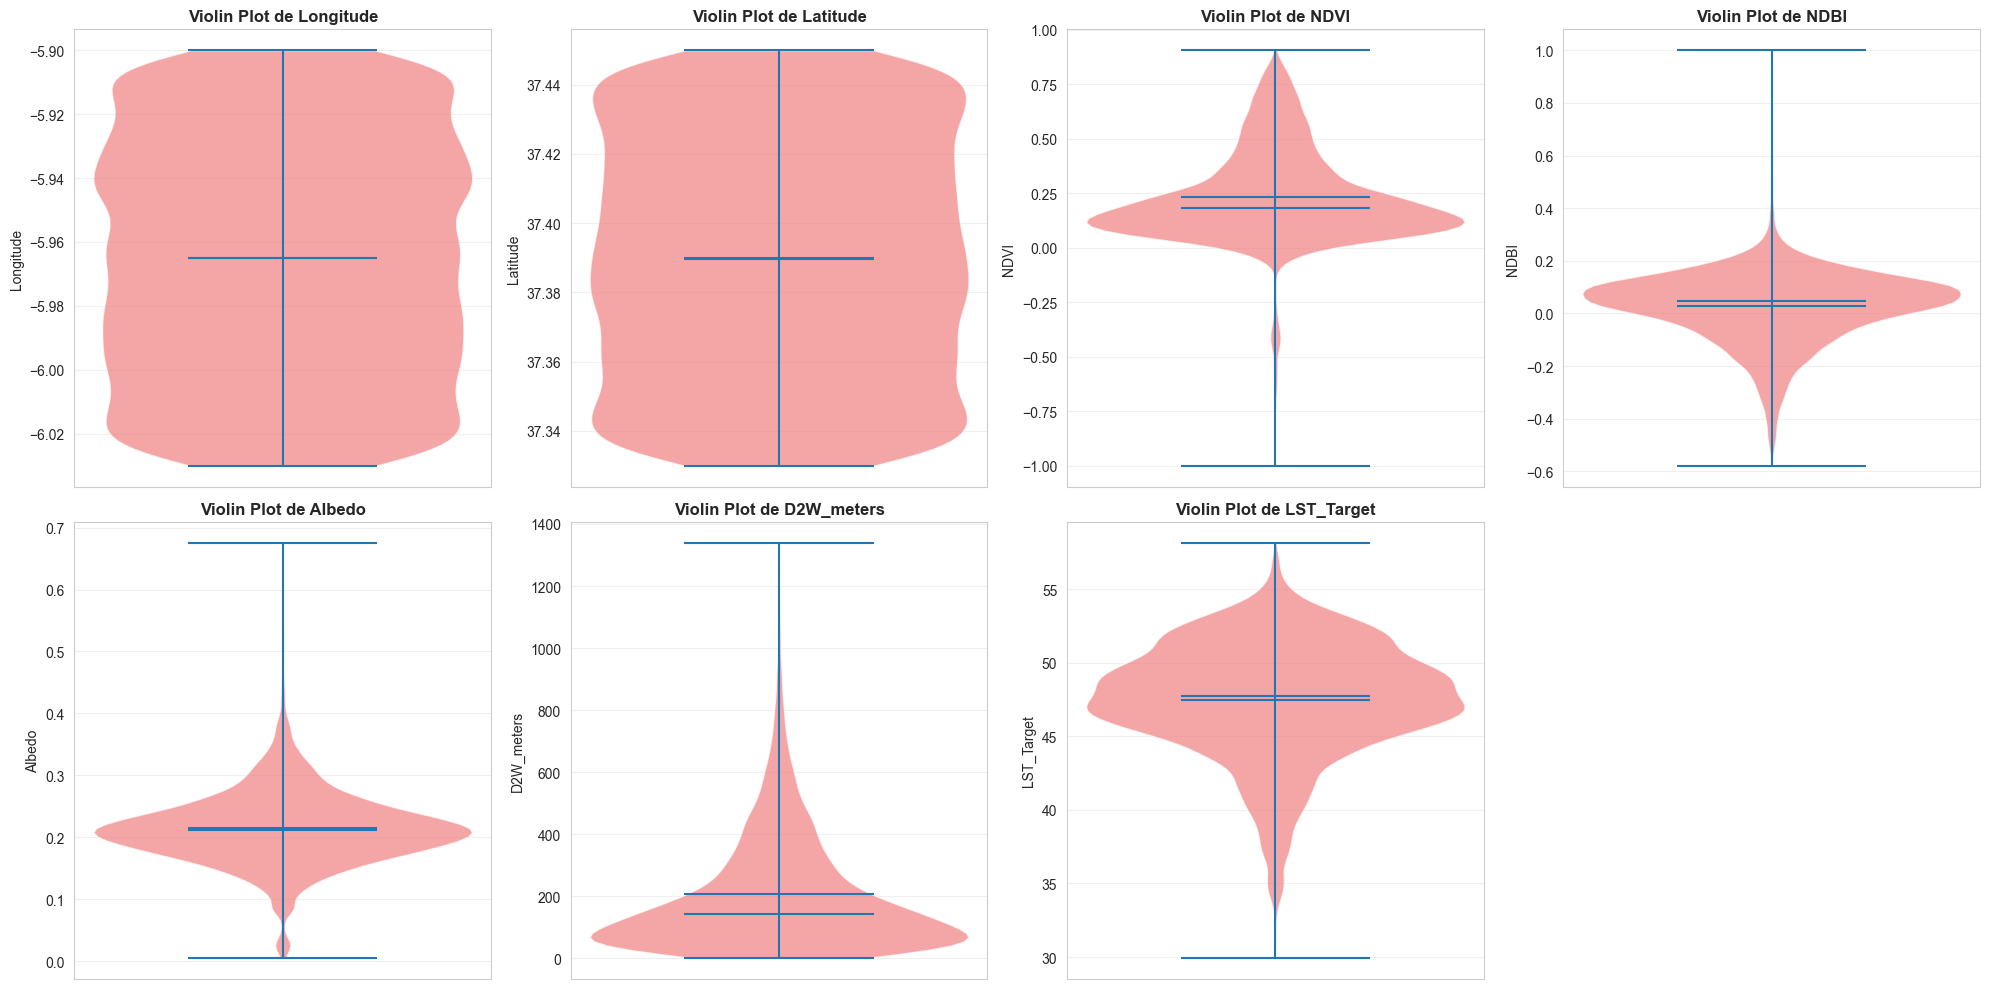

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    sample = df_sample if len(df) > 10000 else df
    parts = axes[idx].violinplot([sample[col]], positions=[0], widths=0.7,
                                showmeans=True, showmedians=True)
    for pc in parts['bodies']:
        pc.set_facecolor('lightcoral')
        pc.set_alpha(0.7)
    axes[idx].set_title(f'Violin Plot de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].set_xticks([])
    axes[idx].grid(True, alpha=0.3, axis='y')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/7_violin_plots.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.8 Densidad 2D: NDVI vs NDBI

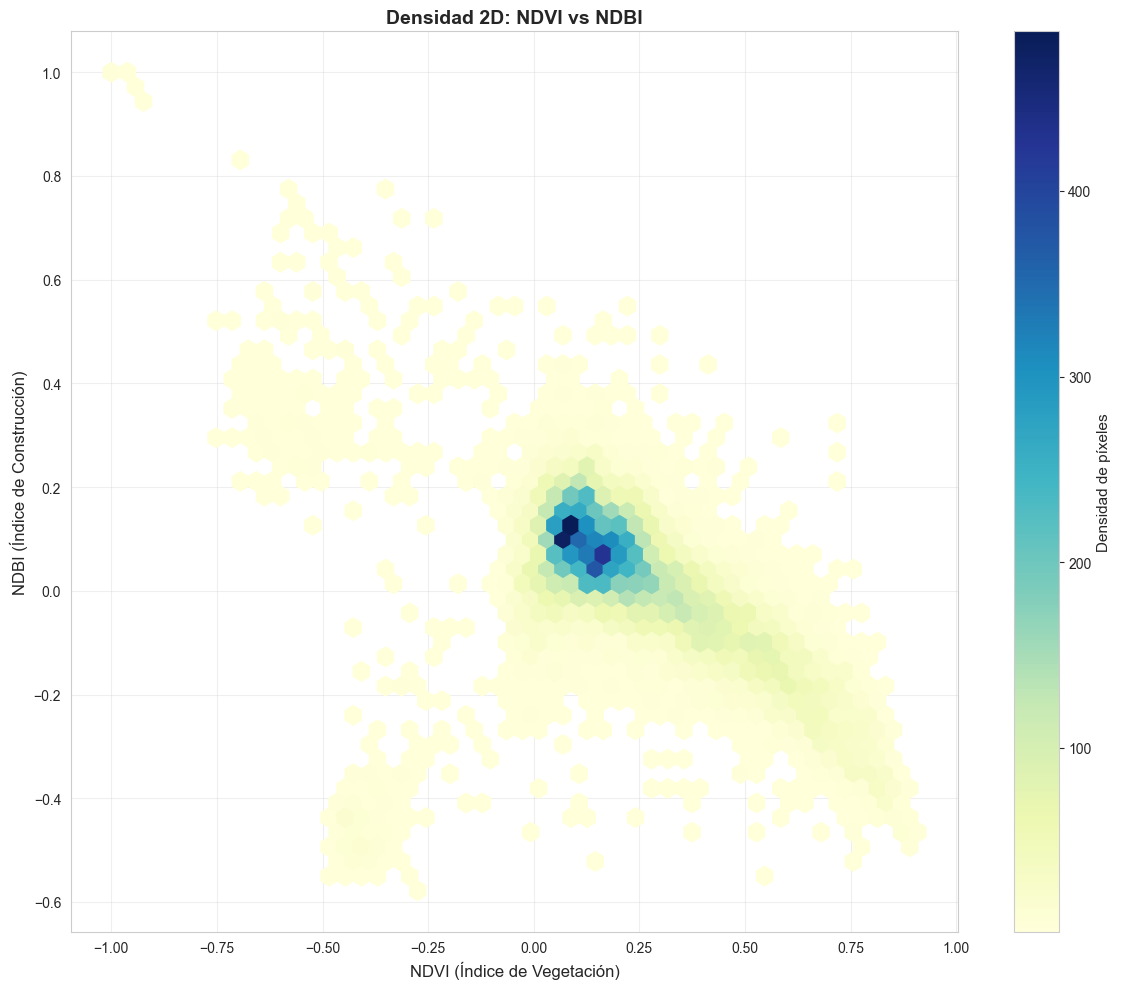

In [14]:
density_sample = df.sample(n=min(20000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 10))
hexbin = ax.hexbin(density_sample['NDVI'], density_sample['NDBI'],
                   gridsize=50, cmap='YlGnBu', mincnt=1)
ax.set_xlabel('NDVI (Índice de Vegetación)', fontsize=12)
ax.set_ylabel('NDBI (Índice de Construcción)', fontsize=12)
ax.set_title('Densidad 2D: NDVI vs NDBI', fontsize=14, fontweight='bold')
cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Densidad de píxeles', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_PLOTS_DIR}/8_densidad_2d_ndvi_ndbi.png", dpi=150, bbox_inches='tight')
plt.show()

## 7. Resumen Ejecutivo

In [61]:
print(f"""
RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS
{'=' * 80}

1. INFORMACIÓN GENERAL:
   - Total de píxeles analizados: {len(df):,}
   - Variables: {', '.join(df.columns)}
   - Valores nulos: {df.isnull().sum().sum()}
   - Duplicados: {df.duplicated().sum()}

2. VARIABLE OBJETIVO (LST_Target):
   - Temperatura media:    {df['LST_Target'].mean():.2f}°C
   - Temperatura mínima:   {df['LST_Target'].min():.2f}°C
   - Temperatura máxima:   {df['LST_Target'].max():.2f}°C
   - Desviación estándar:  {df['LST_Target'].std():.2f}°C
   - Rango térmico:        {df['LST_Target'].max() - df['LST_Target'].min():.2f}°C

3. CORRELACIONES CON LST (ordenadas):
{correlations_with_target.to_string()}

4. PATRONES IDENTIFICADOS:
   - NDVI: [{df['NDVI'].min():.3f}, {df['NDVI'].max():.3f}]
   - NDBI: [{df['NDBI'].min():.3f}, {df['NDBI'].max():.3f}]
   - Distancia al agua: [{df['D2W_meters'].min():.0f}m, {df['D2W_meters'].max():.0f}m]

5. GRÁFICOS GUARDADOS EN: {OUTPUT_PLOTS_DIR}/
   ✓ 1_histogramas.png
   ✓ 2_boxplots.png
   ✓ 3_correlacion_heatmap.png
   ✓ 4_pairplot.png
   ✓ 5_scatter_features_vs_target.png
   ✓ 6_mapa_espacial_lst.png
   ✓ 7_violin_plots.png
   ✓ 8_densidad_2d_ndvi_ndbi.png

{'=' * 80}
✅ Análisis Exploratorio de Datos completado exitosamente.
""")


RESUMEN DEL ANÁLISIS EXPLORATORIO DE DATOS

1. INFORMACIÓN GENERAL:
   - Total de píxeles analizados: 484,356
   - Variables: Longitude, Latitude, NDVI, NDBI, Albedo, D2W_meters, LST_Target
   - Valores nulos: 0
   - Duplicados: 0

2. VARIABLE OBJETIVO (LST_Target):
   - Temperatura media:    47.49°C
   - Temperatura mínima:   29.59°C
   - Temperatura máxima:   58.94°C
   - Desviación estándar:  4.00°C
   - Rango térmico:        29.35°C

3. CORRELACIONES CON LST (ordenadas):
LST_Target    1.000000
NDBI          0.460517
Longitude     0.371592
Albedo        0.362838
D2W_meters    0.056105
Latitude     -0.131786
NDVI         -0.204528

4. PATRONES IDENTIFICADOS:
   - NDVI: [-1.000, 0.928]
   - NDBI: [-0.630, 1.000]
   - Distancia al agua: , 1369m]

5. GRÁFICOS GUARDADOS EN: outputs/eda_plots/
   ✓ 1_histogramas.png
   ✓ 2_boxplots.png
   ✓ 3_correlacion_heatmap.png
   ✓ 4_pairplot.png
   ✓ 5_scatter_features_vs_target.png
   ✓ 6_mapa_espacial_lst.png
   ✓ 7_violin_plots.png
   ✓ 8_densi

In [62]:
# Exportar notebook a HTML con ruta robusta y validaciones
from pathlib import Path
import json
import subprocess
import sys

NOTEBOOK_PATH = Path("main_eda.ipynb").resolve()
OUTPUT_DIR = Path("outputs").resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FILE = OUTPUT_DIR / "reporte_eda_completo.html"

if not NOTEBOOK_PATH.exists():
    raise FileNotFoundError(f"No existe el notebook: {NOTEBOOK_PATH}")

# Si el notebook está vacío, el HTML resultará prácticamente en blanco
with NOTEBOOK_PATH.open("r", encoding="utf-8") as f:
    nb_data = json.load(f)

n_cells = len(nb_data.get("cells", []))
if n_cells == 0:
    raise ValueError(
        "El notebook no tiene celdas. Añade contenido antes de exportar para evitar un HTML en blanco."
    )

print("Exportando notebook a HTML...")
cmd = [
    sys.executable,
    "-m", "jupyter", "nbconvert",
    "--to", "html",
    str(NOTEBOOK_PATH),
    "--output", OUTPUT_FILE.stem,
    "--output-dir", str(OUTPUT_DIR),
]

result = subprocess.run(cmd, capture_output=True, text=True)

if result.returncode == 0 and OUTPUT_FILE.exists() and OUTPUT_FILE.stat().st_size > 0:
    print(f"Notebook exportado correctamente: {OUTPUT_FILE}")
    print(f"Tamaño: {OUTPUT_FILE.stat().st_size / 1024:.1f} KB")
else:
    print("Error al exportar notebook")
    if result.stderr:
        print(result.stderr)

Exportando notebook a HTML...
Notebook exportado correctamente: /Users/mbarrera/uhi-sevilla-ml/outputs/reporte_eda_completo.html
Tamaño: 5427.5 KB
